

# Subárvore Especial (Kruskal)

Dado um grafo conexo, não direcionado e ponderado, encontre a **Realmente Especial Subárvore** (Really Special SubTree). A Realmente Especial Subárvore é definida como um subgrafo que consiste em todos os nós do grafo e:

*   Existe apenas um caminho exclusivo de um nó para qualquer outro nó.
*   O subgrafo possui o peso total mínimo (soma de todas as arestas) entre todos esses subgrafos.
*   Nenhum ciclo é formado.

Para criar a Subárvore Realmente Especial, selecione sempre a aresta com o menor peso. Determine se incluí-la criará um ciclo. Se sim, ignore a aresta. Se houver arestas de peso igual disponíveis:

*   Escolha a aresta que minimiza a soma $(u + v + w)$, onde $u$ e $v$ são vértices e $w$ é o peso da aresta.
*   Se ainda houver um empate, escolha qualquer uma delas.

Imprima o peso total da árvore formada usando as regras.

### Descrição da Função

Complete a função `kruskals` no editor abaixo. Ela deve retornar um inteiro que representa o peso total da subárvore formada.

A função `kruskals` possui os seguintes parâmetros:
*   `g_nodes`: um inteiro que representa o número de nós na árvore.
*   `g_from`: uma matriz de inteiros representando os números dos nós de origem das arestas.
*   `g_to`: uma matriz de inteiros representando os números dos nós de destino das arestas.
*   `g_weight`: uma matriz de inteiros representando os pesos de cada aresta.

### Formato de Entrada

A primeira linha contém dois inteiros separados por espaço, `g_nodes` e `g_edges`, o número de nós e arestas no grafo.
As próximas `g_edges` linhas consistem cada uma em três inteiros separados por espaço, `u`, `v` e `w`, onde `u` e `v` denotam os dois nós entre os quais a aresta não direcionada existe e `w` denota o peso dessa aresta.

### Restrições

**Nota:** Se houver arestas entre o mesmo par de nós com pesos diferentes, elas devem ser consideradas como são, como múltiplas arestas.

### Formato de Saída

Imprima um único inteiro denotando o peso total da Realmente Especial Subárvore.

Aqui estão as representações em ASCII para os dois exemplos fornecidos no problema. O foco é visualizar a estrutura das conexões e os pesos das arestas.

### Exemplo 1: Grafo de 3 Nós
Este é um triângulo simples. No algoritmo de Kruskal, escolhemos as duas arestas mais leves, conectando todos os nós sem fechar o ciclo.

```text
      (5)
   [1]----- [3]
    \       /
 (2) \     / (3)
      \   /
       [2]

MST Resultante:
   [1]       [3]
    \       /
 (2) \     / (3)
      \   /
       [2]
Soma: 2 + 3 = 5
```

---

### Exemplo 2: Grafo de 5 Nós
Neste exemplo, o grafo possui várias conexões redundantes. O caminho "Really Special" acaba formando uma linha que conecta os nós em sequência para minimizar o peso total.

**Grafo Original:**
```text
      (50)
   [1]----- [3]
  / | \     / |
(20)| (70) (30)| (40)
 /  |   \ /   |
[2] |   [4]   /
 \ (90)  |   /
  \ |   (60)/
   [5]-----/
```

**MST (Subárvore de Peso Mínimo):**
Seguindo a regra de sempre pegar a menor aresta que não gera ciclo:
1.  **1-2** (peso 20)
2.  **2-3** (peso 30)
3.  **3-4** (peso 40)
4.  **4-5** (peso 60)

```text
[1]       [3]       [5]
  \       / \       /
  (20)   /   (40)  /
    \   /     \   /
     [2]       [4]
      \       /
      (30)   (60)
```

**Cálculo da Soma:**
$$20 + 30 + 40 + 60 = 150$$

---

### Regras de Desempate (Revisão)
Se você encontrar arestas com o mesmo peso $w$:
*   Calcule $u + v + w$ para cada opção.
*   A que resultar no menor valor deve ser priorizada.
*   Isso garante que a árvore seja "Realmente Especial" e única conforme os critérios do HackerRank.

**Fonte:** [HackerRank - Kruskal (MST): Really Special Subtree](https://www.hackerrank.com/challenges/kruskalmstrsub/problem?isFullScreen=true)

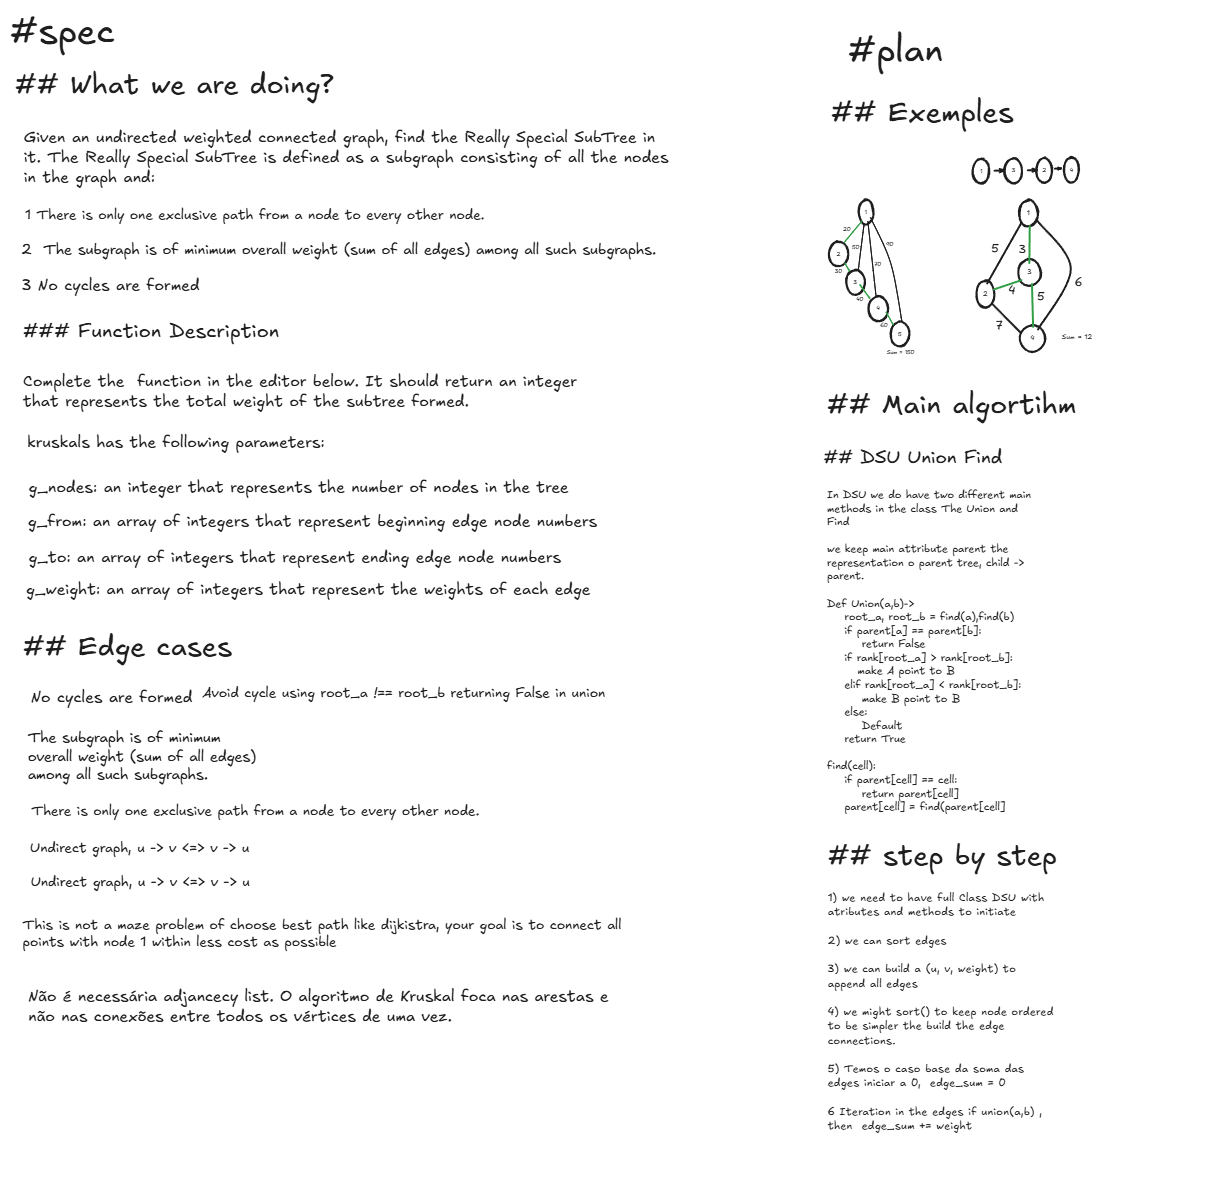

In [ ]:
#!/bin/python3

import os
from typing import List


# =========================================================
# DSU / UNION FIND
# =========================================================

class DSU:

    def __init__(self, n: int):

        self.parent = {}
        self.rank = {}

        for node in range(1, n + 1):

            self.parent[node] = node
            self.rank[node] = 0

    # -----------------------------------------------------

    def find(self, node: int) -> int:

        # path compression
        if self.parent[node] != node:

            self.parent[node] = self.find(
                self.parent[node]
            )

        return self.parent[node]

    # -----------------------------------------------------

    def union(self, a: int, b: int) -> bool:

        root_a = self.find(a)
        root_b = self.find(b)

        # cycle
        if root_a == root_b:
            return False

        # union by rank
        if self.rank[root_a] < self.rank[root_b]:

            self.parent[root_a] = root_b

        elif self.rank[root_a] > self.rank[root_b]:

            self.parent[root_b] = root_a

        else:

            self.parent[root_b] = root_a
            self.rank[root_a] += 1

        return True


# =========================================================
# KRUSKAL MST
# =========================================================

def kruskals(
    g_nodes: int,
    g_edges: int,
    g_from: List[int],
    g_to: List[int],
    g_weight: List[int]
) -> int:

    edges = []

    # build edge list
    for i in range(g_edges):

        edges.append(
            (
                g_weight[i],
                g_from[i],
                g_to[i]
            )
        )

    # sort by weight
    edges.sort()

    dsu = DSU(g_nodes)

    mst_weight = 0

    for weight, u, v in edges:

        # only connect different components
        if dsu.union(u, v):

            mst_weight += weight
    
    print(mst_weight)
    return mst_weight


# =========================================================
# DRIVER
# =========================================================

if __name__ == '__main__':

    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    g_nodes, g_edges = map(
        int,
        input().rstrip().split()
    )

    g_from = [0] * g_edges
    g_to = [0] * g_edges
    g_weight = [0] * g_edges

    for i in range(g_edges):

        (
            g_from[i],
            g_to[i],
            g_weight[i]
        ) = map(
            int,
            input().rstrip().split()
        )

    res = kruskals(
        g_nodes,
        g_edges,
        g_from,
        g_to,
        g_weight
    )

    fptr.write(str(res) + '\n')

    fptr.close()
